<a href="https://colab.research.google.com/github/DayCoh/Initial/blob/main/Sleep_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#There are many research articles regarding what impacts sleep. Causes range from stress to phone usage to caffeine.
#The goal of exploring this data set is to determine if daily_phone_hours and stress_level have a significant impact on sleep_hours independently. If so, which has the greater impact?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
upload = files.upload()
screen_data = pd.read_csv('Smartphone_Usage_Productivity_Dataset_50000.csv')

Saving Smartphone_Usage_Productivity_Dataset_50000.csv to Smartphone_Usage_Productivity_Dataset_50000 (4).csv


In [ ]:
screen_data.head(10)

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9
5,U6,32,Female,Student,Android,10.9,4.2,9,6.3,7,34,5,3.6
6,U7,26,Male,Student,iOS,5.6,6.1,8,6.7,3,5,3,2.9
7,U8,24,Male,Freelancer,iOS,8.5,1.9,4,7.8,3,6,6,12.8
8,U9,52,Female,Business Owner,Android,9.4,2.5,3,6.4,4,17,3,3.1
9,U10,23,Female,Student,iOS,2.8,1.1,1,4.5,2,7,0,2.7


In [ ]:
screen_data.tail(10)

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
49990,U49991,24,Other,Freelancer,iOS,6.1,7.4,9,6.8,6,23,1,2.6
49991,U49992,42,Female,Business Owner,Android,11.1,1.4,6,8.2,7,33,5,8.6
49992,U49993,34,Male,Professional,iOS,10.1,4.1,3,7.3,8,36,3,5.7
49993,U49994,38,Other,Freelancer,Android,2.2,3.1,1,4.1,10,18,4,4.0
49994,U49995,34,Male,Student,Android,4.6,7.0,4,4.4,3,44,3,7.4
49995,U49996,44,Male,Business Owner,Android,5.9,5.4,5,6.6,1,11,5,3.0
49996,U49997,42,Other,Business Owner,Android,2.9,7.4,9,6.3,2,20,4,6.2
49997,U49998,27,Female,Freelancer,iOS,1.4,2.5,4,6.7,9,39,4,5.1
49998,U49999,41,Female,Business Owner,iOS,8.9,3.0,6,5.5,2,51,0,9.2
49999,U50000,46,Other,Freelancer,Android,8.8,2.8,3,5.4,1,54,5,6.9


In [ ]:
#There are no missing values in the data set.
screen_data.isnull().sum()

,0
User_ID,0
Age,0
Gender,0
Occupation,0
Device_Type,0
Daily_Phone_Hours,0
Social_Media_Hours,0
Work_Productivity_Score,0
Sleep_Hours,0
Stress_Level,0


In [ ]:
screen_data.describe()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


<Axes: >

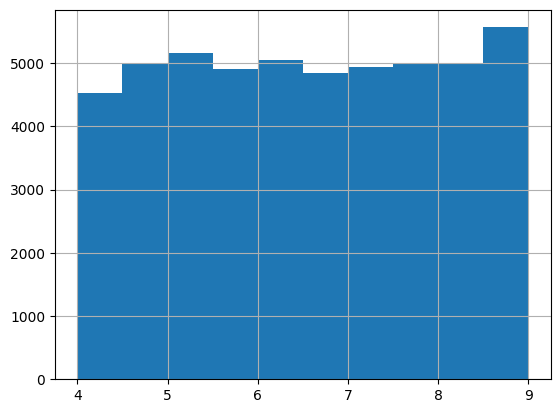

In [ ]:
#The histogram shows most people get 5 or 9 hours of sleep with more people getting between 8 and 9 hours. The histogam is right skewed.
screen_data['Sleep_Hours'].hist()

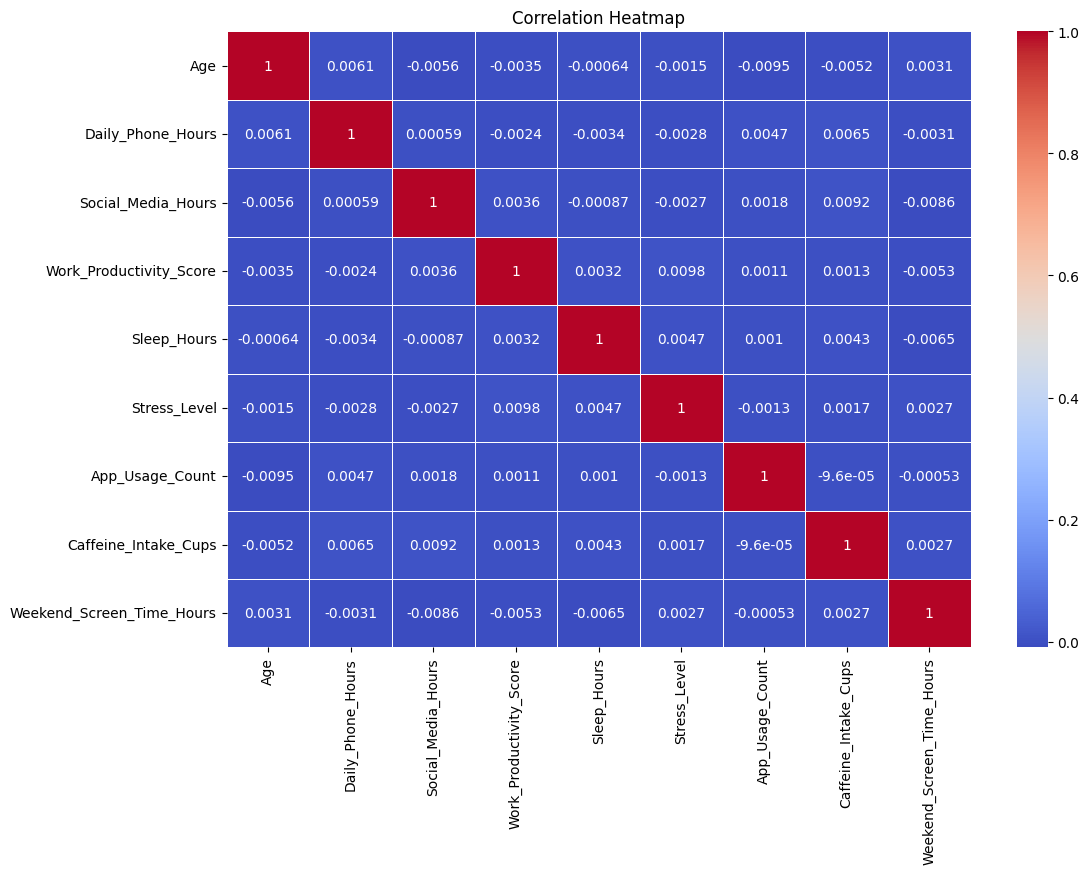

In [ ]:
#Heatmap
#This shows how the features corellate to one another. Daily_Phone_Hours has a -0.0034 corellation to Sleep_Hours. Stress_Level has a 0.0047 correlation to Sleep_Hours.
import seaborn as sns
plt.figure(figsize=(12, 8))
numeric_data = screen_data.select_dtypes(include=np.number)
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidth=0.5)
plt.title('Correlation Heatmap')
plt.show()

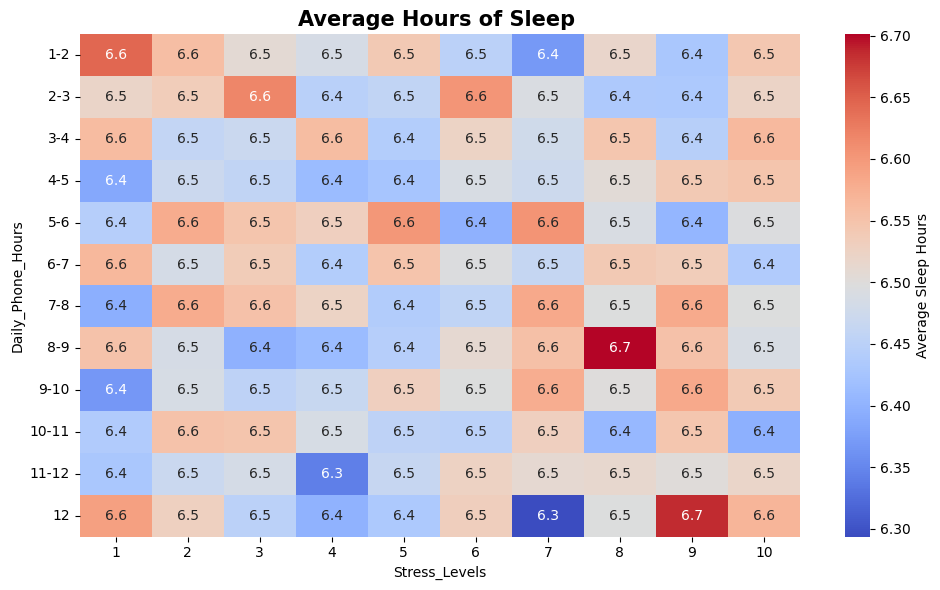

In [ ]:
#The heatmap shows the average hours of sleep by stress level and daily phone hours.
screen_data['Daily_Phone_Hours_Group'] = pd.cut(screen_data['Daily_Phone_Hours'], bins=[1, 1.9, 2.9, 3.9, 4.9, 5.9, 6.9, 7.9, 8.9, 9.9, 10.9, 11.9, 12.0], labels=['1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8', '8-9', '9-10', '10-11', '11-12', '12'])

sleep_heat = (
    screen_data.groupby(['Daily_Phone_Hours_Group', 'Stress_Level'], observed=False)['Sleep_Hours']
      .mean()
      .unstack()
)

plt.figure(figsize=(10, 6))
sns.heatmap(sleep_heat, annot=True, cmap='coolwarm', center=sleep_heat.values.mean(), cbar_kws={'label': 'Average Sleep Hours'})
plt.title('Average Hours of Sleep ', fontsize=15, fontweight='bold')
plt.xlabel('Stress_Levels')
plt.ylabel('Daily_Phone_Hours')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Stress Level Distribution')

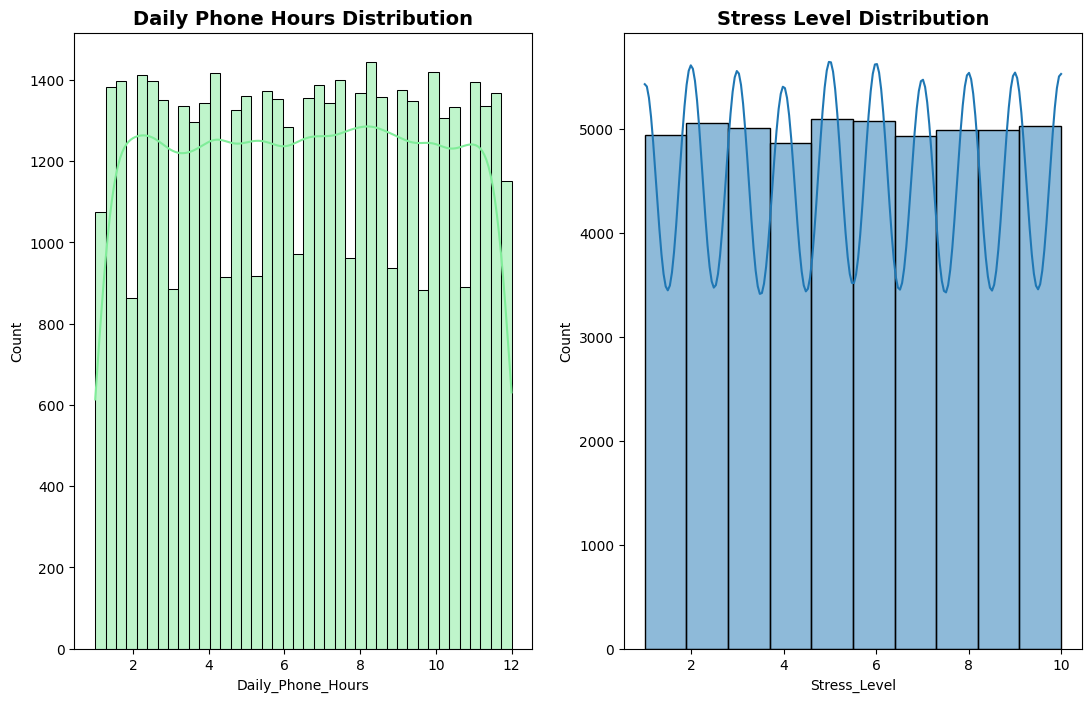

In [ ]:
#The following plots reveal how many people report a stress level between 1 and 10. Also, how many people report using their phones between 1 and 12 hours a day.
fig, axes = plt.subplots(1, 2, figsize=(13, 8))

sns.histplot(screen_data['Daily_Phone_Hours'], bins=40, kde=True, color='#80ed99', ax=axes[0])
axes[0].set_title('Daily Phone Hours Distribution', fontsize=14, fontweight='bold')

sns.histplot(screen_data['Stress_Level'], bins=10, kde=True, color='#1f77b4', ax=axes[1])
axes[1].set_title('Stress Level Distribution', fontsize=14, fontweight='bold')

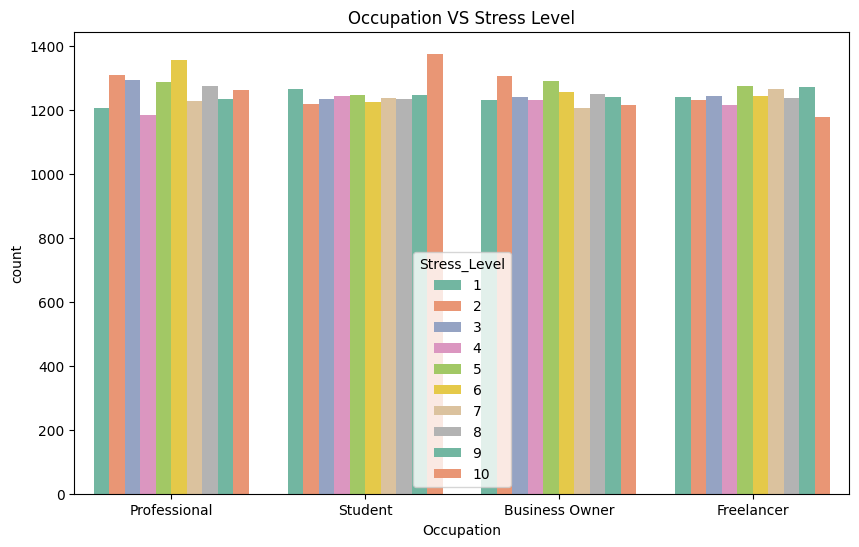

In [ ]:
#Countplot shows stress levels in relation to different occupations.
plt.figure(figsize=(10,6))
sns.countplot(x='Occupation',hue='Stress_Level',data=screen_data, palette='Set2',linewidth=1)
plt.title("Occupation VS Stress Level")
plt.show()

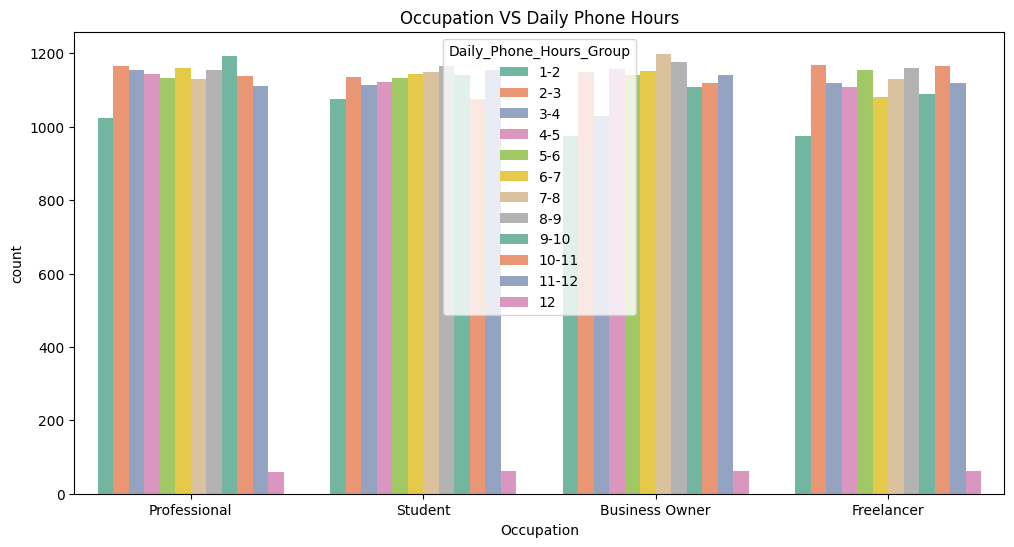

In [ ]:
#CountPlot shows daily phone hours in relation to occupation.
plt.figure(figsize=(12,6))
sns.countplot(x='Occupation',hue='Daily_Phone_Hours_Group',data=screen_data, palette='Set2',linewidth=1)
plt.title("Occupation VS Daily Phone Hours")
plt.show()

In [ ]:
#Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
#Define Independent and Dependent Variables
X = screen_data[['Daily_Phone_Hours', 'Stress_Level']]
y = screen_data['Sleep_Hours']

print(X)
print(y)

       Daily_Phone_Hours  Stress_Level
0                    1.3             4
1                    1.2             1
2                    5.3             4
3                    5.8             3
4                    7.9             3
...                  ...           ...
49995                5.9             1
49996                2.9             2
49997                1.4             9
49998                8.9             2
49999                8.8             1

[50000 rows x 2 columns]
0        8.8
1        6.4
2        9.0
3        5.7
4        5.7
        ... 
49995    6.6
49996    6.3
49997    6.7
49998    5.5
49999    5.4
Name: Sleep_Hours, Length: 50000, dtype: float64


In [ ]:
#Split Data into Training(80%) and Testing (20%) Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Linear Regression Model
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
r_sqr = model.score(X_test,y_test)

print('r2:', r_sqr)
print('intercept:', model.intercept_)
print('coefficient:', model.coef_)

r2: -2.7376649879506942e-05
intercept: 6.500560267858312
coefficient: [-0.00225581  0.0018772 ]


In [ ]:
y_pred = model.predict(X_test)

print('predicted values:', y_pred)

predicted values: [6.49888489 6.50115654 6.48912029 ... 6.49512257 6.50662718 6.48167614]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

#Model's performance using  mean squared error (MSE), mean absolute error (MAE), and R-squared score
print(f"Mean Absolute Error (MAE): {mae: .6f}")
print(f"Mean Squared Error (MSE): {mse: .6f}")
print(f"R-squared Score (R²): {r2: .5f}")

Mean Absolute Error (MAE):  1.258618
Mean Squared Error (MSE):  2.108641
R-squared Score (R²): -0.00003


In [ ]:
#Based on the R², the linear regression model performed poorly for this dataset. This means the data is not linear.
#The linear regression model is off by 1.26 units. There is a large squared error difference between the actual and predicted values. The model does not capture the underlying pattern in the data.
#The coefficients reveal daily phone hours has a negative or less significant impact on sleep than stress levels.
#Daily phone hours decrease sleep by -0.00225581 (7 seconds). Stress levels increase sleep by 0.0018772 (7 seconds).
#Daily phone hours and stress levels do not have a meaningful impact on hours of sleep.

In [ ]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn import tree

In [ ]:
#Define Independent and Dependent Variables
X = screen_data[['Daily_Phone_Hours', 'Stress_Level']]
y = screen_data['Sleep_Hours']

print(X)
print(y)

       Daily_Phone_Hours  Stress_Level
0                    1.3             4
1                    1.2             1
2                    5.3             4
3                    5.8             3
4                    7.9             3
...                  ...           ...
49995                5.9             1
49996                2.9             2
49997                1.4             9
49998                8.9             2
49999                8.8             1

[50000 rows x 2 columns]
0        8.8
1        6.4
2        9.0
3        5.7
4        5.7
        ... 
49995    6.6
49996    6.3
49997    6.7
49998    5.5
49999    5.4
Name: Sleep_Hours, Length: 50000, dtype: float64


In [ ]:
#Split Data into Training(80%) and Testing (20%) Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Utilize Regression Model
dtree = DecisionTreeRegressor(
    max_depth = 4,
    min_samples_leaf = 100,
    random_state = 42
)
dtree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=42)

In [ ]:
y_pred = dtree.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae: .6f}")
print(f"Mean Squared Error (MSE): {mse: .6f}")
print(f"R-squared Score (R²): {r2: .5f}")

Mean Absolute Error (MAE):  1.258991
Mean Squared Error (MSE):  2.111534
R-squared Score (R²): -0.00140


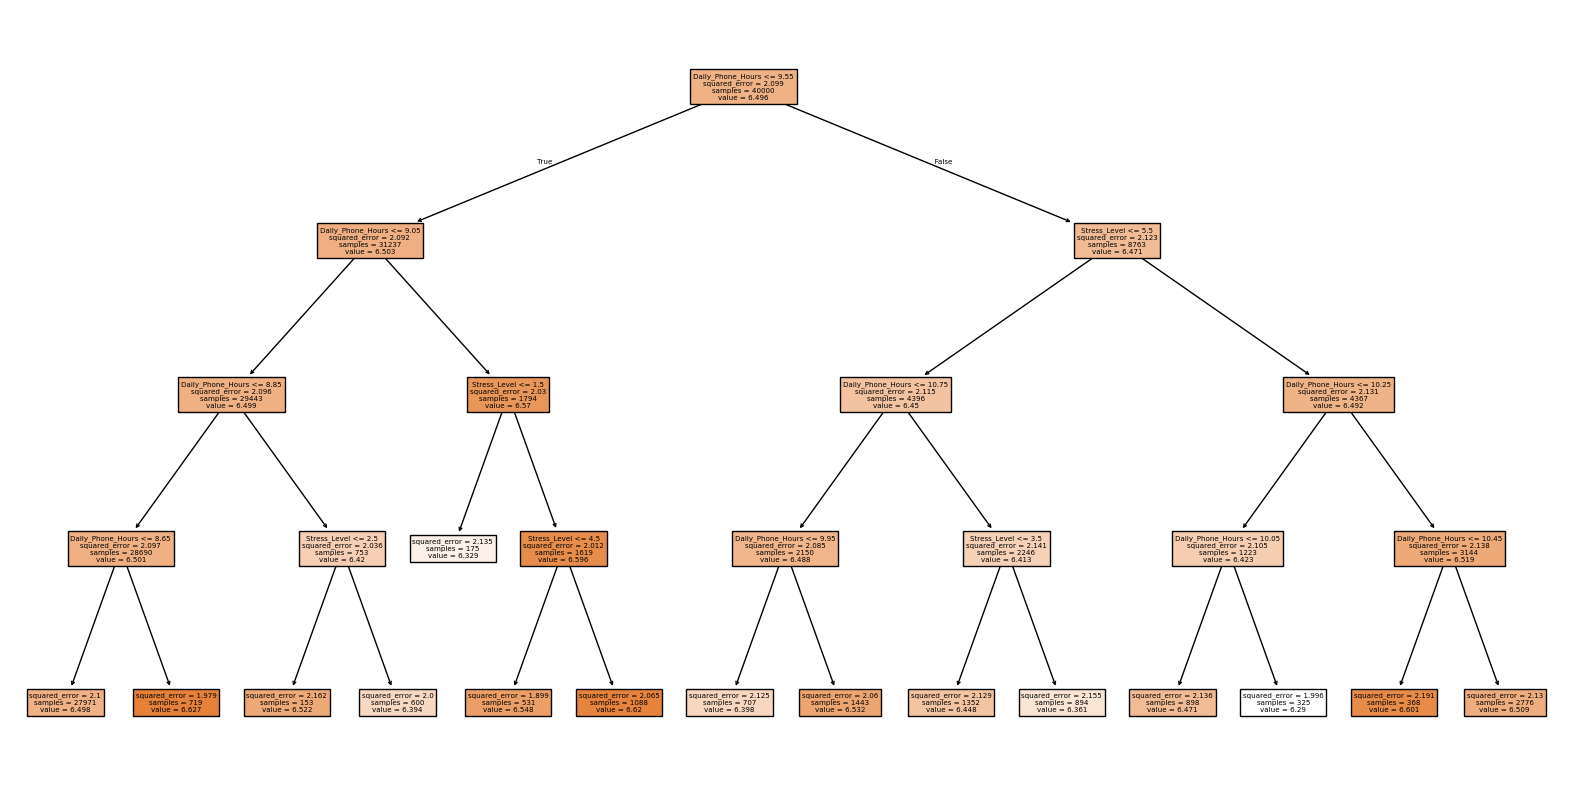

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(dtree, feature_names=['Daily_Phone_Hours', 'Stress_Level'], filled=True)
plt.show()

In [ ]:
dtree.feature_importances_

array([0.73948012, 0.26051988])

In [ ]:
#The decision tree(-0.00140) performed worse than the linear regression model(-0.00003).

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

In [ ]:
#Define Independent and Dependent Variables
X = screen_data[['Daily_Phone_Hours', 'Stress_Level']]
y = screen_data['Sleep_Hours']

print(X)
print(y)

       Daily_Phone_Hours  Stress_Level
0                    1.3             4
1                    1.2             1
2                    5.3             4
3                    5.8             3
4                    7.9             3
...                  ...           ...
49995                5.9             1
49996                2.9             2
49997                1.4             9
49998                8.9             2
49999                8.8             1

[50000 rows x 2 columns]
0        8.8
1        6.4
2        9.0
3        5.7
4        5.7
        ... 
49995    6.6
49996    6.3
49997    6.7
49998    5.5
49999    5.4
Name: Sleep_Hours, Length: 50000, dtype: float64


In [ ]:
#Split Data into Training(80%) and Testing (20%) Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
rf = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=20, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(min_samples_leaf=20, n_estimators=300, random_state=42)

In [ ]:
r_sqr = model.score(X_test,y_test)

print('r2:', r_sqr)
print('intercept:', model.intercept_)
print('coefficient:', model.coef_)

r2: -2.7376649879506942e-05
intercept: 6.500560267858312
coefficient: [-0.00225581  0.0018772 ]


In [ ]:
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rf.feature_importances_

print(f"Mean Absolute Error (MAE): {mae: .6f}")
print(f"Mean Squared Error (MSE): {mse: .6f}")
print(f"R-squared Score (R²): {r2: .5f}")
print("Feature Importances:", rf.feature_importances_)

Mean Absolute Error (MAE):  1.266853
Mean Squared Error (MSE):  2.145929
R-squared Score (R²): -0.01771
Feature Importances: [0.64621356 0.35378644]


In [ ]:
#The random forest (-0.01771) performed worse than the decision tree (-0.00140).

I selected the lnear regression model first to determine if the data was linear. As a result of the poor performance (R-squared Score (R²): -0.00003) I determined the correlation is not linear.

I then used the decision tree model because it works well with large data and non-linear data. This model performed poorly (R-squared Score (R²): -0.00140) while using 74% of daily phone hours data and 26% stress level data to make its predictions.

The final model used was the random forest. This also works well with large and non-linear data, while maintaining stability. While performing poorly (R-squared Score (R²): -0.01771), this model used 65% of daily phone hours data and 35% of stress level data.

All models produced similar results, with none out performing the other. They produced consistently negative R² values, an MAE of ~ 1.26 hours and an MSE of ~ 2.1. The coefficients (-0.00225581  0.0018772) show the low meaningful impact the features have on hours of sleep. When splitting the data, the decision tree and random forest collected most of their values from daily phone hours (74% and 65% respectively). This means daily phone hours has a greater impact than stress in the models, but there is no strong correlation to sleep.

R², MAE, and MSE were used because they are standard metrics for evaluating regression models. R² measures explained variance, while MAE and MSE quantify prediction error. These metrics are more appropriate than classification metrics because sleep hours is a continuous variable.

Based on the linear regression, decision tree, and random forest model, daily phone usage and stress levels do not have a strong independent impact on sleep. Sleep is multifaceted and is affected by many things like caffeine intake, health, and much more. The models show that daily phone usage and stress levels have a weak impact on sleep alone.

The linear regression model produced the lowest R², MAE, and MSE values. This means it performed better than the other models, with random forest performing the worst. This means the complex models may have overfit the noise within the data.